In [60]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [61]:
DATASETS = ["mnist", "cifar_10", "stl_10"]
MODELS = ["esn", "bi_esn", "bi_esn2d"]
UNITS = [128, 256, 512, 1024]
CV_LIST = [0, 1, 2, 3, 4]
SEED_LIST = [0, 1, 2]

In [62]:
# acc,f1,top5,connectivity,leaky,spectral_radius,beta
def get_results(csv_file: str) -> dict[tuple[str, str, int], pd.DataFrame]:
    COLUMNS = [
        "seed",
        "cv",
        "acc",
        "f1",
        "top5",
        "connectivity",
        "leaky",
        "spectral_radius",
        "beta",
    ]

    df = pd.read_csv(csv_file)
    results = {}

    for ds in DATASETS:
        for m in MODELS:
            for u in UNITS:
                key = (ds, m, u)

                results[key] = df[(df["dataset"] == ds) & (df["model"] == m) & (df["units"] == u)][COLUMNS].reset_index(
                    drop=True
                )

    return results

In [63]:
CSV_FILE = "/home/nakanishi/WORKSPACE/bidirectional_2D_reservoir_computing/results/nm2026_out/results.csv"

results = get_results(CSV_FILE)

best acc

In [64]:
best_units = {
    "mnist": {"esn": 256, "bi_esn": 512, "bi_esn2d": 512},
    "cifar_10": {"esn": 128, "bi_esn": 128, "bi_esn2d": 256},
    "stl_10": {"esn": 512, "bi_esn": 512, "bi_esn2d": 512},
}

for ds in DATASETS:
    for m in MODELS:
        u = best_units[ds][m]

        acc_list = results[(ds, m, u)]["acc"].values

        acc_mean = np.mean(acc_list)
        acc_std = np.std(acc_list)

        print(f"{ds} - {m} - {u} units: acc = {acc_mean:.3f} ± {acc_std:.3f}")

mnist - esn - 256 units: acc = 0.871 ± 0.011
mnist - bi_esn - 512 units: acc = 0.910 ± 0.027
mnist - bi_esn2d - 512 units: acc = 0.924 ± 0.002
cifar_10 - esn - 128 units: acc = 0.408 ± 0.005
cifar_10 - bi_esn - 128 units: acc = 0.413 ± 0.004
cifar_10 - bi_esn2d - 256 units: acc = 0.476 ± 0.004
stl_10 - esn - 512 units: acc = 0.365 ± 0.007
stl_10 - bi_esn - 512 units: acc = 0.372 ± 0.005
stl_10 - bi_esn2d - 512 units: acc = 0.395 ± 0.006


箱ひげ図

In [65]:
def plot_boxplot_fixed_bestunits(
    results: dict[tuple[str, str, int], pd.DataFrame],
    dataset: str,
    best_units: dict[str, dict[str, int]],
    metric: str = "acc",
    model_order: list[str] = ["esn", "bi_esn", "bi_esn2d"],
    jitter_std: float = 0.03,
    save_path: str | None = None,
):
    """
    固定された best_units を使って箱ひげ図を描く。
    """

    box_data = []
    labels = []

    for model in model_order:
        if dataset not in best_units:
            continue
        if model not in best_units[dataset]:
            continue

        units = best_units[dataset][model]
        key = (dataset, model, units)

        if key not in results:
            continue

        df = results[key]
        if df.empty:
            continue

        y = df[metric].to_numpy()
        box_data.append(y)
        labels.append(f"{model} ({units})")

    if len(box_data) == 0:
        raise ValueError(f"No data available for dataset={dataset}")

    plt.figure()
    plt.boxplot(box_data)

    # scatter overlay
    for i, y in enumerate(box_data, start=1):
        x = np.random.normal(loc=i, scale=jitter_std, size=len(y))
        plt.scatter(x, y)

    # 表示用整形
    ds_name = dataset.upper() if dataset != "cifar_10" else "CIFAR-10"
    metric_name = "Accuracy" if metric == "acc" else metric

    plt.xticks(range(1, len(labels) + 1), labels)
    plt.ylabel(metric_name)
    plt.title(f"{ds_name}: {metric_name} (best units)")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

In [66]:
for ds in ["mnist", "cifar_10", "stl_10"]:
    plot_boxplot_fixed_bestunits(
        results,
        dataset=ds,
        best_units=best_units,
        metric="acc",
        save_path=os.path.join(
            "../results/nm2026_figures",
            f"boxplot_{ds}.png",
        ),
    )

ハイパーパラメータの収束

In [67]:
HP_CONVERTER = {
    "connectivity": "Connectivity",
    "leaky": "Leaky Rate",
    "spectral_radius": "Spectral Radius",
    "beta": "Beta",
}

MODEL_CONVERTER = {
    "esn": "UniESN",
    "bi_esn": "BiESN",
    "bi_esn2d": "BiESN2D",
}

DS_CONVERTER = {
    "mnist": "MNIST",
    "cifar_10": "CIFAR-10",
    "stl_10": "STL-10",
}

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_hp_scatter_2x2(results, best_units, save_path=None):

    # -----------------------------
    # 🔥 フォントサイズ一括設定
    # -----------------------------
    plt.rcParams.update(
        {
            "font.size": 16,
            "axes.titlesize": 28,
            "axes.labelsize": 18,
            "xtick.labelsize": 25,
            "ytick.labelsize": 18,
            "legend.fontsize": 18,
            "legend.title_fontsize": 15,
            "figure.titlesize": 20,
        }
    )

    models = ("esn", "bi_esn", "bi_esn2d")
    datasets = ("mnist", "cifar_10", "stl_10")

    markers = {"mnist": "o", "cifar_10": "^", "stl_10": "s"}
    xoff = {"mnist": -0.15, "cifar_10": 0.0, "stl_10": +0.15}
    xmap = {m: i for i, m in enumerate(models)}

    panels = [
        ("spectral_radius", HP_CONVERTER["spectral_radius"]),
        ("leaky", HP_CONVERTER["leaky"]),
        ("connectivity", HP_CONVERTER["connectivity"]),
        ("log10_beta", r"$\log_{10}\beta$"),
    ]

    # --- データ整形 ---
    rows = []
    for ds in datasets:
        for m in models:
            u = best_units.get(ds, {}).get(m)
            if u is None:
                continue

            df = results.get((ds, m, u))
            if df is None or df.empty:
                continue

            for r in df.itertuples(index=False):
                beta = getattr(r, "beta")
                rows.append(
                    {
                        "dataset": ds,
                        "model": m,
                        "acc": getattr(r, "acc"),
                        "connectivity": getattr(r, "connectivity"),
                        "leaky": getattr(r, "leaky"),
                        "spectral_radius": getattr(r, "spectral_radius"),
                        "log10_beta": np.log10(max(beta, 1e-12)),
                    }
                )

    if not rows:
        raise ValueError("No rows matched.")

    accs = [r["acc"] for r in rows]
    vmin, vmax = min(accs), max(accs)

    fig, axes = plt.subplots(2, 2, figsize=(16, 7), constrained_layout=True)
    axes = axes.ravel()

    for i, (ax, (col, title)) in enumerate(zip(axes, panels)):
        for ds in datasets:
            sub = [r for r in rows if r["dataset"] == ds]
            if not sub:
                continue

            x = [xmap[r["model"]] + xoff[ds] + np.random.normal(0.0, 0.05) for r in sub]
            y = [r[col] for r in sub]
            c = [r["acc"] for r in sub]

            ax.scatter(
                x,
                y,
                c=c,
                vmin=vmin,
                vmax=vmax,
                marker=markers[ds],
                s=60,  # 点も少し大きく
            )

        ax.set_xticks(range(len(models)))
        if i < 2:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels([MODEL_CONVERTER[m] for m in models])
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.3)

    # Legend
    legend = [
        Line2D(
            [0],
            [0],
            marker=markers[ds],
            color="w",
            markerfacecolor="gray",
            markersize=20,
            linestyle="None",
            label=DS_CONVERTER[ds],
        )
        for ds in datasets
    ]

    fig.legend(
        handles=legend,
        title="Dataset",
        loc="lower center",
        ncol=len(datasets),
        bbox_to_anchor=(0.5, -0.15),
        frameon=False,
    )

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

    return fig

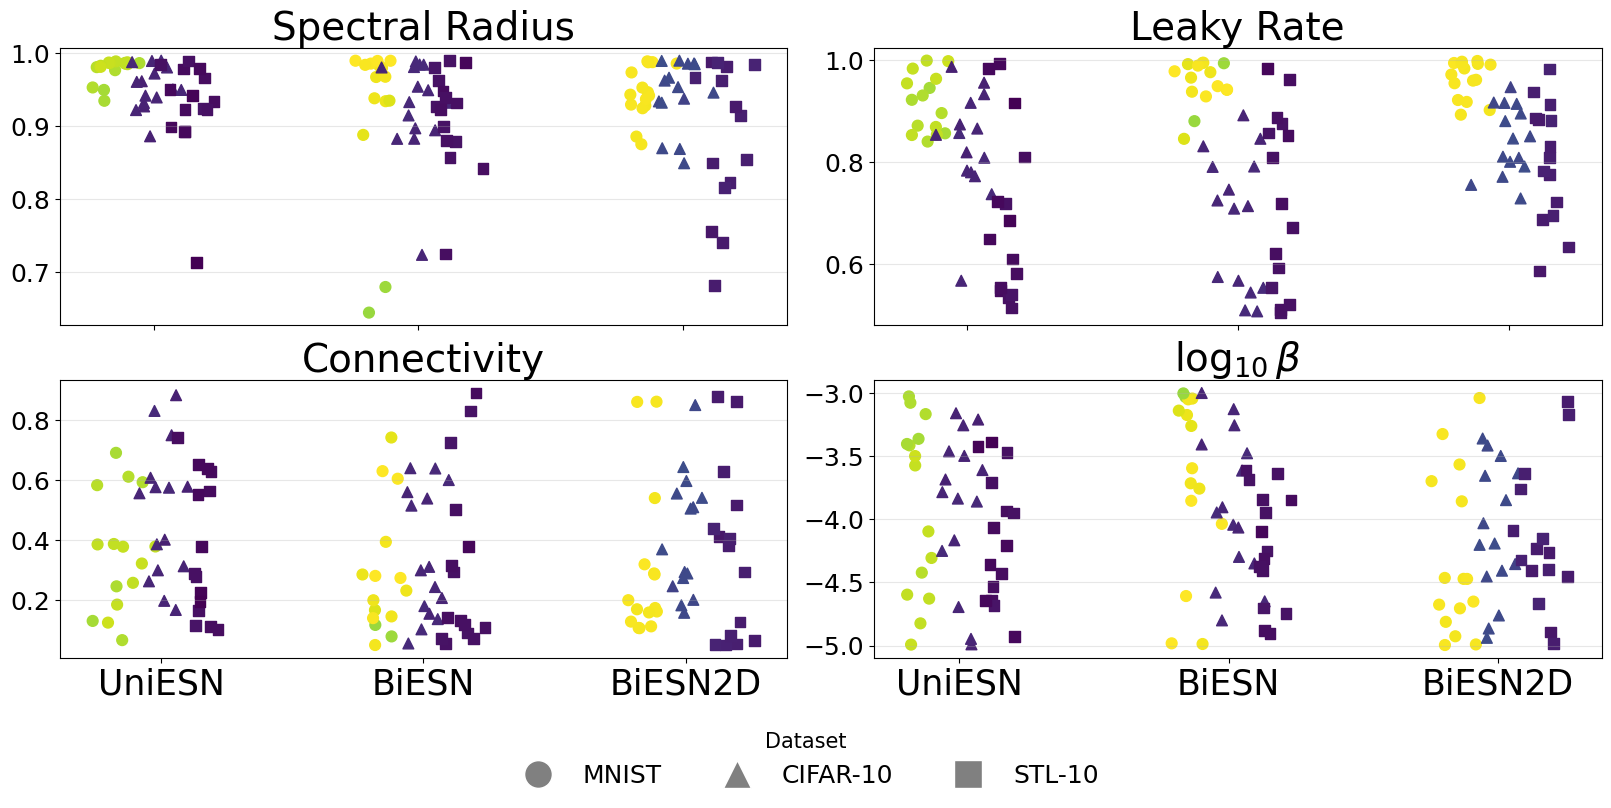

In [82]:
plot_hp_scatter_2x2(
    results,
    best_units,
    save_path=os.path.join(
        "../results/nm2026_figures",
        "hp_scatter_2x2.png",
    ),
)

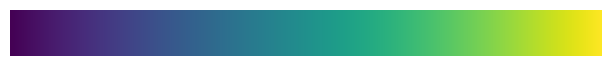

In [83]:
# colorbarの描画
cmap = plt.get_cmap("viridis")
cbar = np.linspace(0, 1, 256).reshape(1, -1)
cbar = np.tile(cbar, (20, 1))  # 縦に伸ばす

plt.figure()
plt.imshow(cbar, cmap=cmap)
plt.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join("../results/nm2026_figures", "accuracy_colorbar.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

/tmp/ipykernel_2993068/2091679084.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


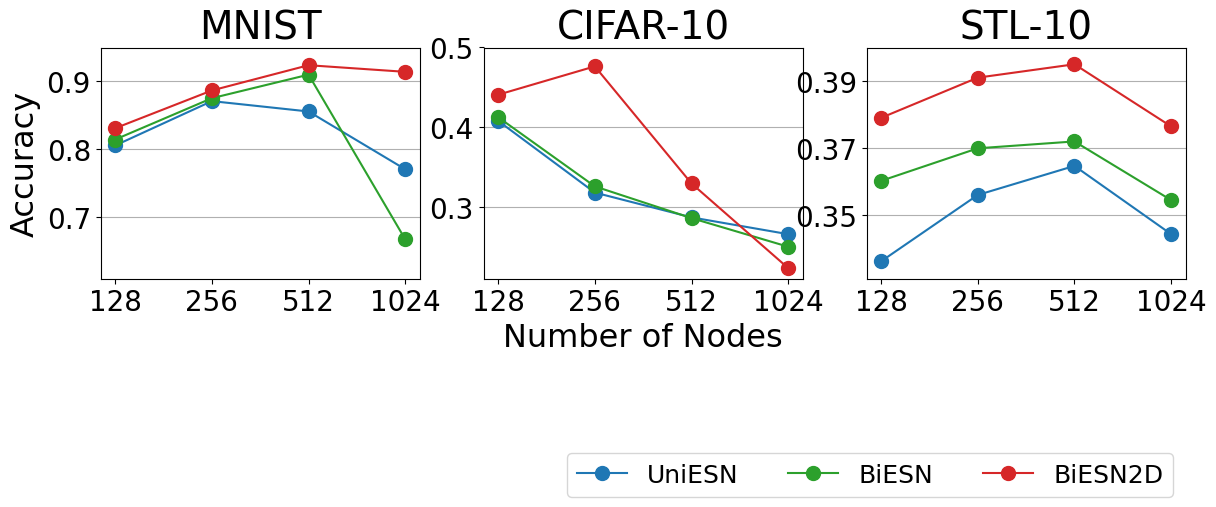

In [84]:
YLIM_DICT = {
    "mnist": (0.61, 0.95),
    "cifar_10": (0.21, 0.5),
    "stl_10": (0.331, 0.4),
}
YTIKS_DICT = {
    "mnist": np.arange(0.6, 0.95 + 1e-8, 0.1),
    "cifar_10": np.arange(0.2, 0.5 + 1e-8, 0.1),
    "stl_10": np.arange(0.33, 0.4 + 1e-8, 0.02),
}

cmap = plt.get_cmap("tab10")
COLORS_DICT = {
    "esn": cmap(0),
    "bi_esn": cmap(2),
    "bi_esn2d": cmap(3),
}

plt.figure(figsize=(14, 3))
for ds in DATASETS:
    plt.subplot(1, len(DATASETS), DATASETS.index(ds) + 1)
    plt.title(DS_CONVERTER[ds], fontsize=28)
    plt.xticks(range(len(UNITS)), UNITS, fontsize=20)
    if DATASETS.index(ds) == 0:
        plt.ylabel("Accuracy", fontsize=23)
    plt.yticks(YTIKS_DICT[ds], fontsize=20)
    # plt.ylim(YLIM_DICT[ds])
    plt.ylim(YLIM_DICT[ds])
    plt.grid(axis="y")

    if DATASETS.index(ds) == 1:
        plt.xlabel("Number of Nodes", fontsize=23)

    for i, m in enumerate(MODELS):
        units_acc = []
        for j, u in enumerate(UNITS):
            key = (ds, m, u)
            if key not in results:
                print(f"Missing key: {key}")
                continue

            df = results[key]
            if df.empty:
                print(f"Empty DataFrame for key: {key}")
                continue

            accs = df["acc"].values
            acc_mean = np.mean(accs)

            units_acc.append(acc_mean)
        plt.plot(units_acc, marker="o", label=MODEL_CONVERTER[m], color=COLORS_DICT[m], markersize=10)
plt.legend(
    loc="lower right",
    ncol=3,
    bbox_to_anchor=(1.0, -1),
)
plt.tight_layout()
plt.savefig(
    os.path.join("../results/nm2026_figures", "accuracy_by_units.png"),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()